# Customer Churn Prediction
End-to-end workflow: Business Problem → Data → Preparation → EDA → Feature Engineering → Model → Evaluation → Interpretation → Saved Model → API.

**Required split:** 70:30  
**Random state:** 42


In [1]:
from pathlib import Path
import sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.feature_engineering import TelcoFeatureEngineer

df = pd.read_csv(ROOT / "data" / "TelcoCustomerChurn.csv")
df.head()


Matplotlib is building the font cache; this may take a moment.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Understanding & Preparation

In [2]:
print("Shape:", df.shape)
print(df.dtypes)
print("\nBlank values:")
print(df.astype(str).apply(lambda s: s.str.strip().eq("").sum()).sort_values(ascending=False).head())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())
print("\nChurn distribution:")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).mul(100).round(2))


Shape: (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Blank values:
TotalCharges     11
gender            0
SeniorCitizen     0
Partner           0
customerID        0
dtype: int64

Duplicate rows: 0
Duplicate customer IDs: 0

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


### Observations
- 7,043 rows and 21 original columns.
- `TotalCharges` contains 11 blanks and is therefore read as text. We convert it to numeric and impute missing values inside the pipeline.
- No duplicate rows/customer IDs.
- Churn is about 26.5%, so accuracy alone is insufficient.
- `customerID` is excluded from modelling because it is an identifier.
- All learned preprocessing occurs after the train/test split inside a pipeline, avoiding leakage.


## 2. Exploratory Data Analysis

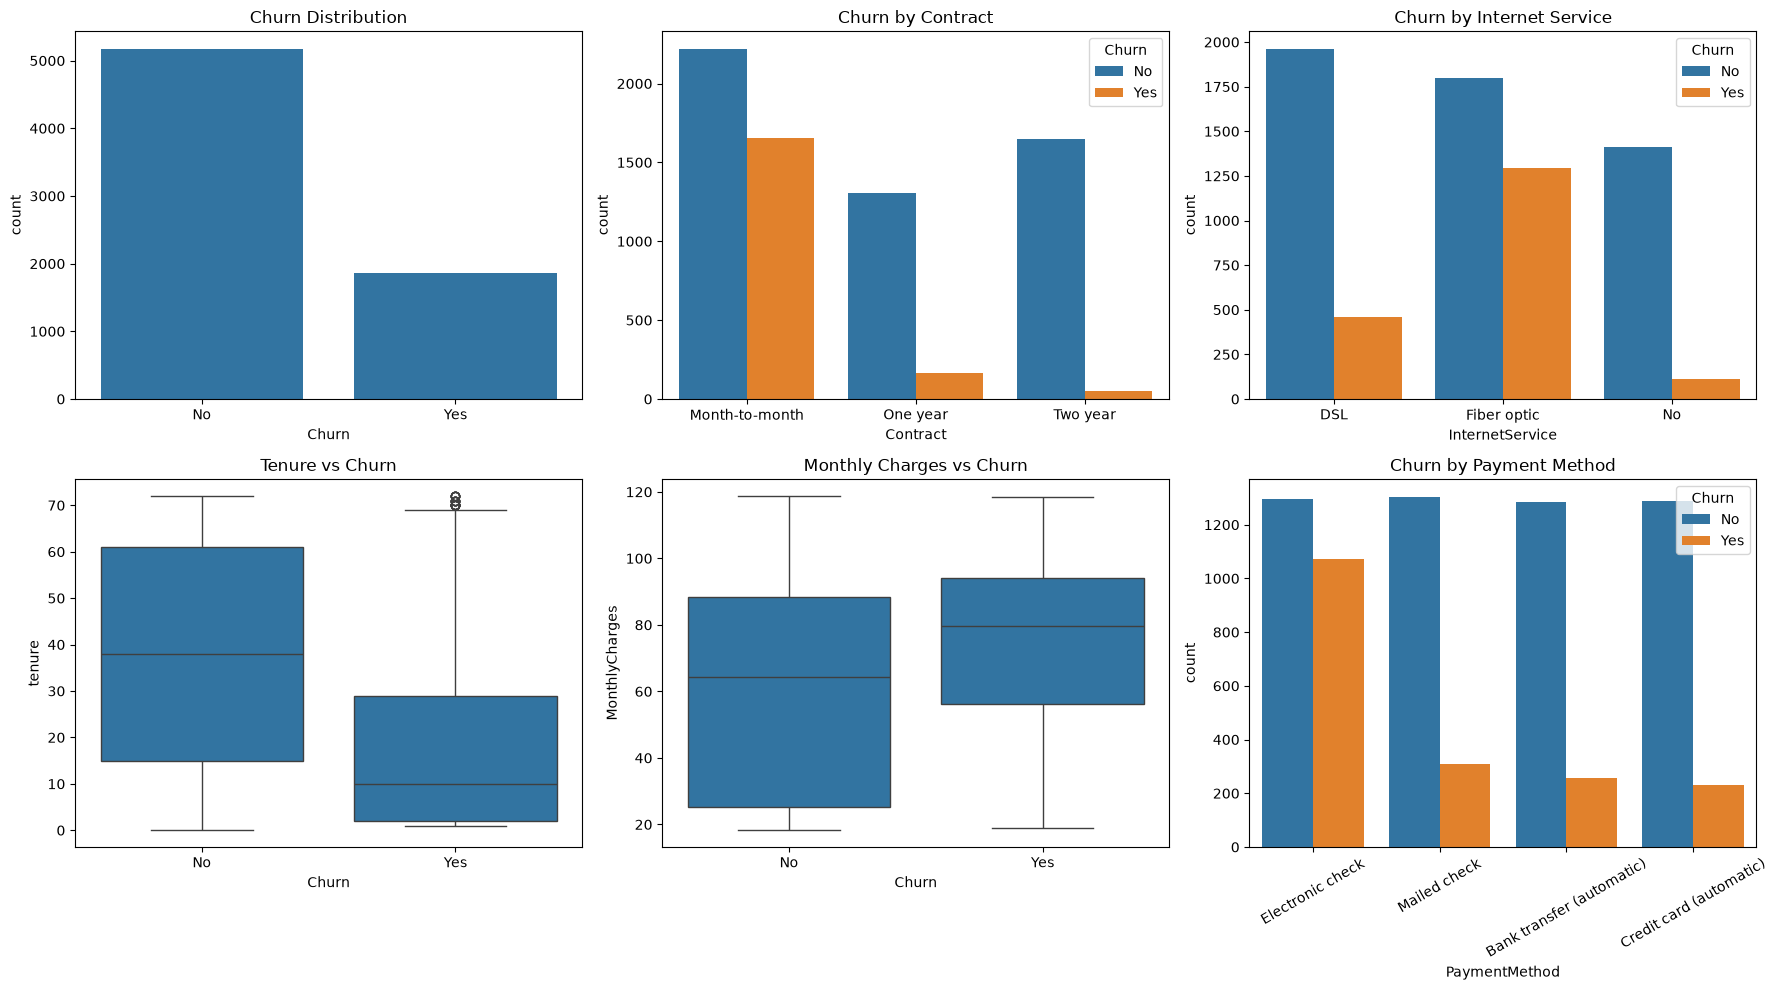

In [3]:
fig, axes = plt.subplots(2,3,figsize=(18,10))
sns.countplot(data=df,x="Churn",ax=axes[0,0]); axes[0,0].set_title("Churn Distribution")
sns.countplot(data=df,x="Contract",hue="Churn",ax=axes[0,1]); axes[0,1].set_title("Churn by Contract")
sns.countplot(data=df,x="InternetService",hue="Churn",ax=axes[0,2]); axes[0,2].set_title("Churn by Internet Service")
sns.boxplot(data=df,x="Churn",y="tenure",ax=axes[1,0]); axes[1,0].set_title("Tenure vs Churn")
sns.boxplot(data=df,x="Churn",y="MonthlyCharges",ax=axes[1,1]); axes[1,1].set_title("Monthly Charges vs Churn")
sns.countplot(data=df,x="PaymentMethod",hue="Churn",ax=axes[1,2]); axes[1,2].tick_params(axis="x",rotation=30); axes[1,2].set_title("Churn by Payment Method")
plt.tight_layout(); plt.show()


### EDA business insights
1. Churners are the minority, requiring precision/recall/F1 in addition to accuracy.
2. Month-to-month customers churn more often than customers with longer contracts.
3. Fiber-optic customers show a higher churn tendency.
4. Churners generally have shorter tenure, highlighting early-lifecycle risk.
5. Churners tend to have higher monthly charges, suggesting price/value sensitivity.
6. Electronic-check customers show elevated churn and may deserve targeted analysis.


## 3. Feature Engineering
**NumServices:** counts services with value `Yes`, capturing relationship depth.  
**TenureGroup:** converts raw tenure into lifecycle bands, capturing non-linear churn patterns.


In [4]:
X = df.drop(columns=["Churn"])
y = (df["Churn"]=="Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

numeric_features = ["tenure","MonthlyCharges","TotalCharges","NumServices"]
categorical_features = [
    "gender","SeniorCitizen","Partner","Dependents","PhoneService","MultipleLines",
    "InternetService","OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies","Contract",
    "PaperlessBilling","PaymentMethod","TenureGroup"
]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer",SimpleImputer(strategy="median"))]), numeric_features),
    ("cat", Pipeline([
        ("imputer",SimpleImputer(strategy="most_frequent")),
        ("onehot",OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

def make_pipeline(tree):
    return Pipeline([
        ("features",TelcoFeatureEngineer()),
        ("preprocess",preprocessor),
        ("model",tree)
    ])


## 4. Model Development

In [5]:
configs = {
    "Baseline": make_pipeline(DecisionTreeClassifier(random_state=42)),
    "Pruned": make_pipeline(DecisionTreeClassifier(max_depth=5,min_samples_leaf=20,random_state=42))
}
rows=[]
for name, model in configs.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test); prob=model.predict_proba(X_test)[:,1]
    rows.append([name,accuracy_score(y_test,pred),precision_score(y_test,pred),recall_score(y_test,pred),f1_score(y_test,pred),roc_auc_score(y_test,prob)])

pd.DataFrame(rows,columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC"]).round(4)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline,0.7265,0.4853,0.4991,0.4921,0.6548
1,Pruned,0.7941,0.6145,0.6025,0.6085,0.8287


### Bonus: Hyperparameter tuning + class-imbalance handling

In [6]:
grid = GridSearchCV(
    make_pipeline(DecisionTreeClassifier(random_state=42)),
    {
        "model__max_depth":[4,5,6],
        "model__min_samples_leaf":[10,20],
        "model__criterion":["gini","entropy"],
        "model__class_weight":[None,"balanced"]
    },
    scoring="f1", cv=4, n_jobs=-1
)
grid.fit(X_train,y_train)
final_model = grid.best_estimator_
print(grid.best_params_)


{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_leaf': 20}


## 5. Model Evaluation

{'accuracy': 0.7487, 'precision': 0.5183, 'recall': 0.7576, 'f1': 0.6155, 'roc_auc': 0.8274}
              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.81      1552
       Churn       0.52      0.76      0.62       561

    accuracy                           0.75      2113
   macro avg       0.71      0.75      0.71      2113
weighted avg       0.79      0.75      0.76      2113



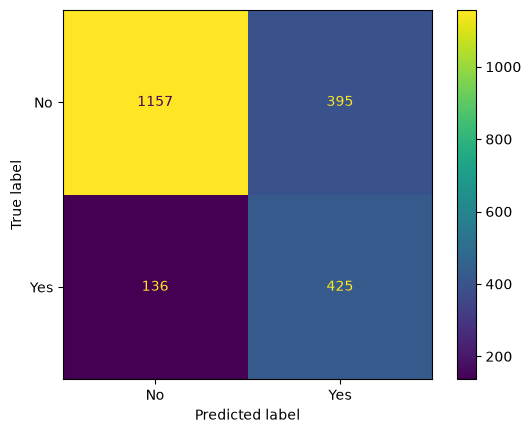

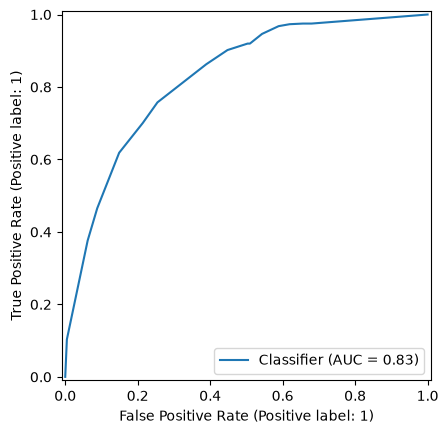

In [7]:
pred=final_model.predict(X_test)
prob=final_model.predict_proba(X_test)[:,1]

print({
    "accuracy":round(accuracy_score(y_test,pred),4),
    "precision":round(precision_score(y_test,pred),4),
    "recall":round(recall_score(y_test,pred),4),
    "f1":round(f1_score(y_test,pred),4),
    "roc_auc":round(roc_auc_score(y_test,prob),4)
})
print(classification_report(y_test,pred,target_names=["No Churn","Churn"]))

ConfusionMatrixDisplay.from_predictions(y_test,pred,display_labels=["No","Yes"])
plt.show()
RocCurveDisplay.from_predictions(y_test,prob)
plt.show()


### Precision vs Recall
For proactive churn retention, **Recall should generally receive higher priority** when contacting an extra non-churner is cheaper than failing to identify a real churner. Missing a churner is a false negative and loses the opportunity for intervention. Precision still matters because very low precision can waste retention capacity.


## 6. Model Interpretation

,feature,importance
38,cat__Contract_Month-to-month,0.653438
0,num__tenure,0.113895
18,cat__InternetService_Fiber optic,0.108821
1,num__MonthlyCharges,0.038365
20,cat__OnlineSecurity_No,0.019917
36,cat__StreamingMovies_No internet service,0.017697
29,cat__TechSupport_No,0.015850
45,cat__PaymentMethod_Electronic check,0.015369
39,cat__Contract_One year,0.006365
2,num__TotalCharges,0.005831


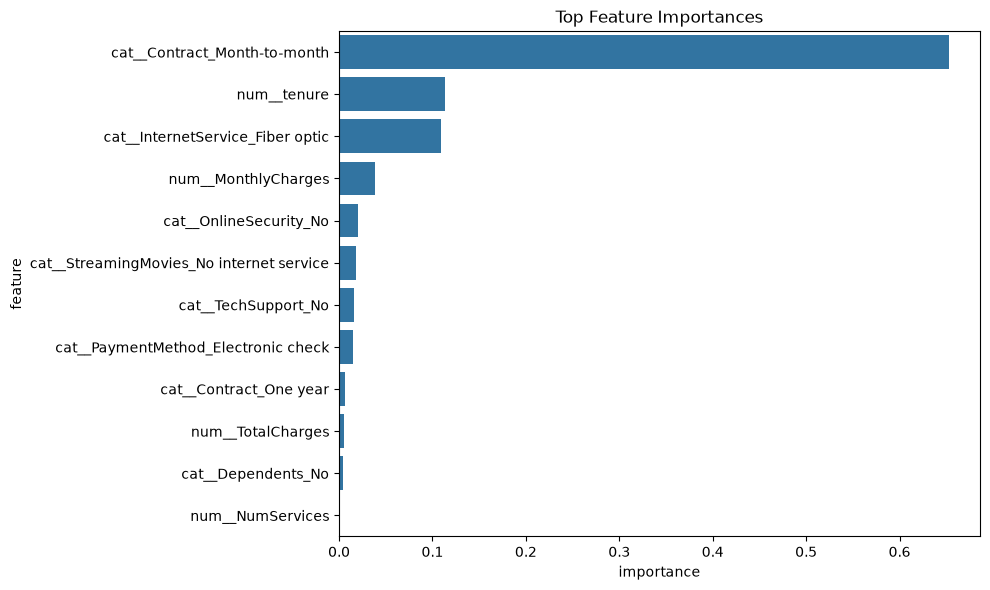

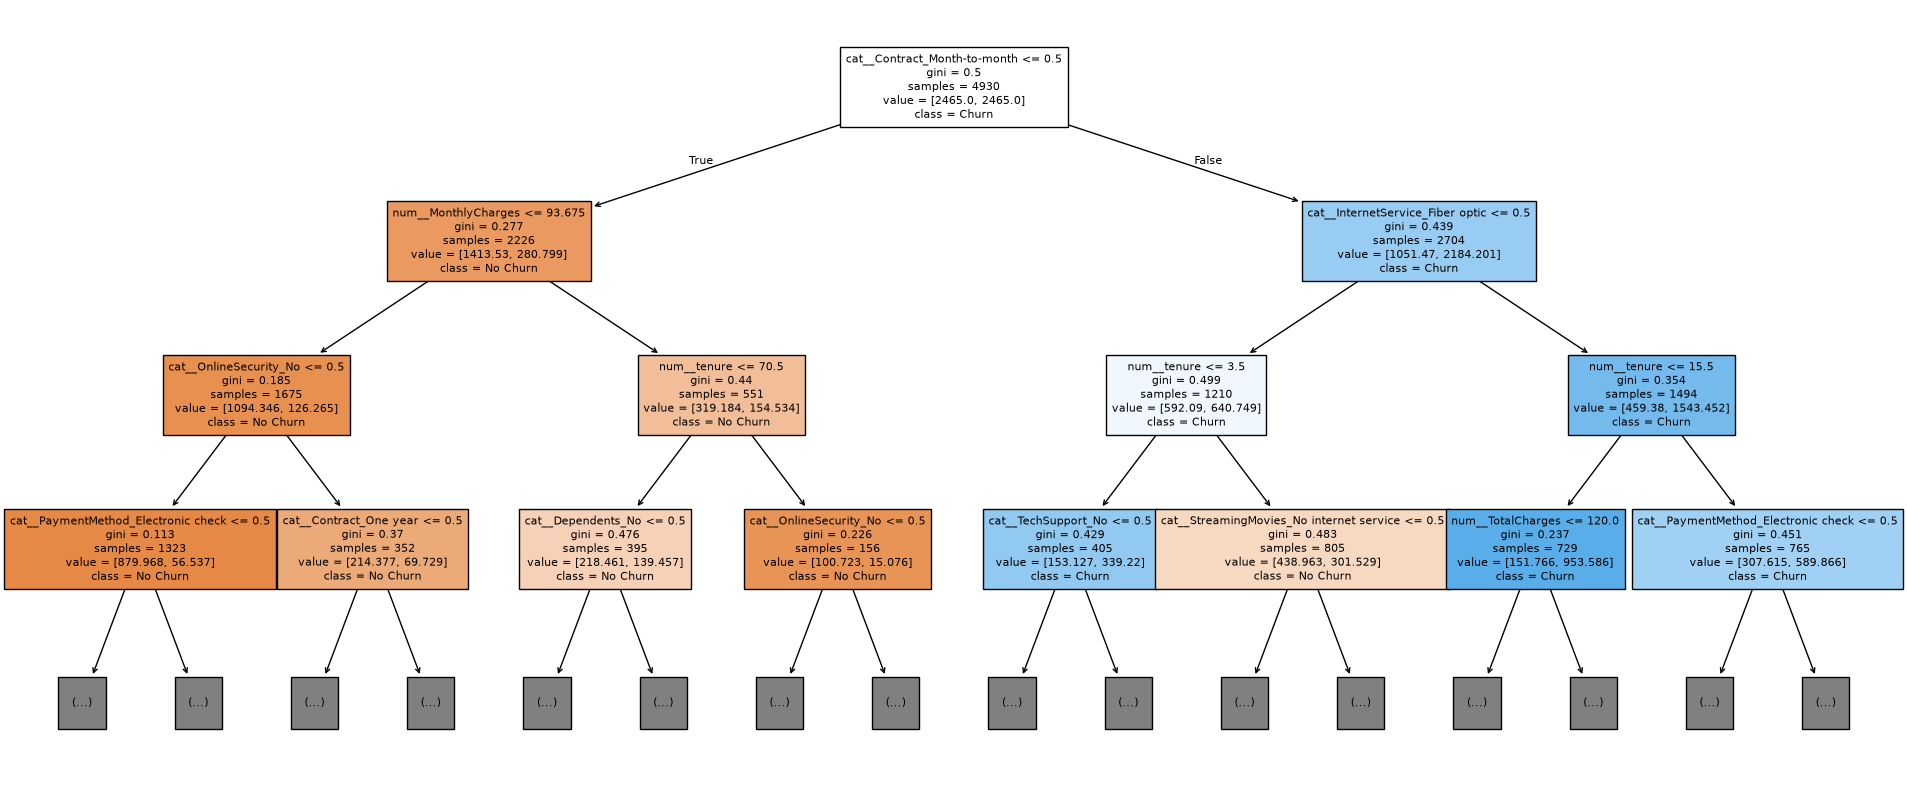

In [8]:
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()
importance = pd.DataFrame({
    "feature":feature_names,
    "importance":final_model.named_steps["model"].feature_importances_
}).sort_values("importance",ascending=False)

display(importance.head(15))
plt.figure(figsize=(10,6))
sns.barplot(data=importance.head(12),x="importance",y="feature")
plt.title("Top Feature Importances")
plt.tight_layout(); plt.show()

plt.figure(figsize=(24,10))
plot_tree(final_model.named_steps["model"], feature_names=feature_names,
          class_names=["No Churn","Churn"], filled=True, max_depth=3, fontsize=8)
plt.show()


### Key findings
The model's strongest signals are typically customer lifecycle/tenure, contract type, charges and service/support characteristics. These findings are consistent with the EDA and are operationally useful for defining retention segments.


## 7. Save Reusable Pipeline

In [9]:
joblib.dump(final_model, ROOT / "model" / "churn_model.pkl")
print("Model saved.")


Model saved.


## Bonus included
- GridSearchCV
- class-weight handling for imbalance
- ROC-AUC
- stratified split
- reusable training script
- Pydantic API validation
- full preprocessing and feature engineering serialized in the model pipeline
